<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/Labs/Lab9_uML_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Mean Clustering using sklearn

In [2]:
from sklearn.datasets import make_classification

 # Generate random data with two features and one cluster/target label

X, y = make_classification(n_samples=200, n_features=2, n_classes=3, n_clusters_per_class=1, n_informative=2, n_redundant=0, random_state=0)

X,y



(array([[ 1.20120424,  2.68585849],
        [-0.47565612,  1.27888341],
        [ 1.85445232,  0.02177088],
        [ 0.12692666,  0.02418069],
        [-0.98887301,  0.78891079],
        [-1.84733219,  0.7181598 ],
        [-2.27039869,  0.7146886 ],
        [ 1.56968042, -2.34787726],
        [ 1.00671517,  0.62443754],
        [-0.87432656,  0.71681344],
        [ 0.52276605, -0.7188685 ],
        [ 0.96815935, -0.91566499],
        [ 0.02271892,  1.73743499],
        [ 1.35360805,  1.67300665],
        [-0.21360694,  1.32166991],
        [-2.13163526,  0.41254111],
        [ 0.76253223,  1.61199303],
        [-0.66716811,  1.27256807],
        [ 0.13738716,  2.63339007],
        [-1.10271319, -2.81899406],
        [ 1.98734896, -0.56250671],
        [ 2.28166504, -0.35061669],
        [ 0.68050218, -0.79675418],
        [-0.18493983,  1.80714016],
        [-2.28810495,  0.626327  ],
        [-1.2607126 ,  0.8950888 ],
        [ 1.0069467 , -0.06671705],
        [ 0.84121147,  1.572

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###Creating a Dataframe from the generated data

In [4]:
df = pd.DataFrame(X)
df['y']= y



df.columns = ['X1', 'X2', 'Y']
df

,X1,X2,Y
0,1.201204,2.685858,1
1,-0.475656,1.278883,0
2,1.854452,0.021771,2
3,0.126927,0.024181,2
4,-0.988873,0.788911,0
...,...,...,...
195,0.020843,1.029939,0
196,0.662639,-1.150929,2
197,2.077741,-1.610384,2
198,-1.710734,0.684729,0


### Create DataFrame without the cluster column

In [5]:
df1 = df.drop(['Y'], axis=1)
df1

,X1,X2
0,1.201204,2.685858
1,-0.475656,1.278883
2,1.854452,0.021771
3,0.126927,0.024181
4,-0.988873,0.788911
...,...,...
195,0.020843,1.029939
196,0.662639,-1.150929
197,2.077741,-1.610384
198,-1.710734,0.684729


### Having a feel of the data by visualising it oon a scatter plot

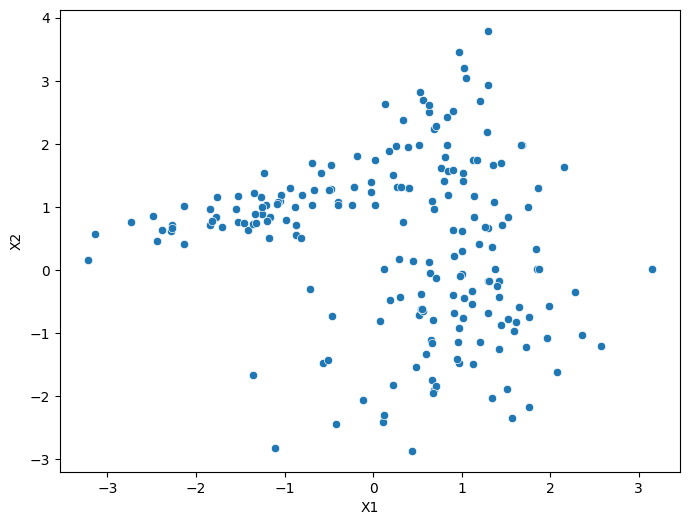

In [6]:
fig, ax=plt.subplots(figsize = (8,6))
ax = sns.scatterplot(x= 'X1', y= 'X2', data=df)

### Building and testing the K Mean Model

In [7]:
from sklearn.cluster import KMeans

In [8]:
kmeans = KMeans(n_clusters=3)
kmeans

KMeans(n_clusters=3)

In [9]:
# Inertia value
KModel = kmeans.fit(df1)
KModel.inertia_

187.91367060704124

### Predicted clustering from KMean Model

In [10]:
KModel.labels_

array([0, 2, 1, 1, 2, 2, 2, 1, 0, 2, 1, 1, 0, 0, 0, 2, 0, 2, 0, 1, 1, 1,
       1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 1, 0, 2, 2, 1, 2, 2, 1, 0, 1, 1, 2,
       0, 0, 0, 0, 1, 2, 1, 2, 0, 0, 0, 2, 2, 1, 0, 2, 0, 1, 2, 1, 2, 1,
       2, 0, 0, 2, 1, 1, 1, 1, 0, 1, 0, 2, 2, 2, 1, 1, 0, 2, 0, 2, 2, 2,
       2, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1, 0, 0, 1, 0, 2,
       1, 2, 0, 2, 0, 2, 1, 0, 0, 2, 1, 1, 1, 2, 0, 1, 0, 0, 1, 0, 2, 0,
       0, 2, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 2,
       1, 2, 0, 1, 2, 2, 0, 2, 1, 2, 1, 1, 1, 0, 0, 0, 2, 0, 1, 1, 2, 1,
       1, 0, 0, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       2, 2], dtype=int32)

In [11]:
# Checking the performance of the Model

pd.crosstab(df.Y, KModel.labels_)

col_0,0,1,2
Y,,,
0,11,0,55
1,51,17,0
2,1,64,1


In [12]:
Y_train = KModel.labels_
df['Y_train'] = Y_train
df

,X1,X2,Y,Y_train
0,1.201204,2.685858,1,0
1,-0.475656,1.278883,0,2
2,1.854452,0.021771,2,1
3,0.126927,0.024181,2,1
4,-0.988873,0.788911,0,2
...,...,...,...,...
195,0.020843,1.029939,0,0
196,0.662639,-1.150929,2,1
197,2.077741,-1.610384,2,1
198,-1.710734,0.684729,0,2


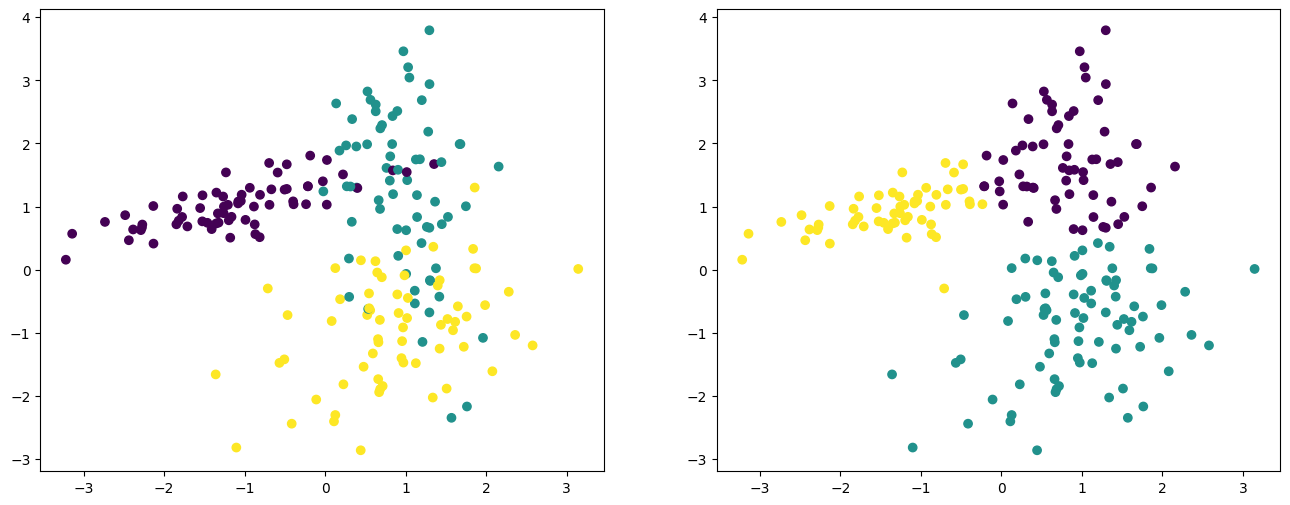

In [13]:
# Two plots showing the actual and modelled clustering labels
# Model not too bad!!!

fig, (ax,bx)= plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ax.scatter(df["X1"], df["X2"], c=df["Y"])
bx.scatter(df["X1"], df["X2"], c=df["Y_train"]);